# Figure 5 · Model deployment workflow, benchmark matrix, and probability calibration

> A: Deployment flowchart (sequence → model → calibration)
> B: Multidimensional benchmark matrix (per-drug OOD AUROC + Brier)
> C：Probability calibration under Subtype OOD（class level）
> Supplementary: epistasis control showing ESM gain does not come from pairwise site interactions.

In [1]:
%matplotlib inline
from __future__ import annotations
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import pandas as pd

# ── paths ─────────────────────────────────────────────────────────────────
CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "work" / "results").exists() else CWD.parent
OOD_DATA  = PROJECT_ROOT / "work" / "results" / "probe_ood_full_selected_k.csv"
EPI_DATA  = PROJECT_ROOT / "work" / "results" / "probe_q5_epistasis.csv"
PRED_DATA = PROJECT_ROOT / "results" / "notebooks" / "fig4" / "fig4_subtype_ood_predictions.csv"
FIG_DIR   = PROJECT_ROOT / "figures" / "manuscript" / "fig5"
OUT_DIR   = PROJECT_ROOT / "results" / "notebooks" / "fig5"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── palette / constants ───────────────────────────────────────────────────
CLASS_ORDER  = ["PI", "NRTI", "NNRTI", "INI"]
CLASS_COLOR  = {"PI":"#0072B2","NRTI":"#E69F00","NNRTI":"#009E73","INI":"#CC79A7"}
CLASS_MARKER = {"PI":"o","NRTI":"s","NNRTI":"^","INI":"D"}
CC = CLASS_COLOR; CO = CLASS_ORDER
SURFACE,INK,INK2,INK3,GRID = "#fcfcfb","#0b0b0b","#52514e","#8a8984","#e0dfdb"
GPOS="#009E73"; GNEG="#D55E00"; GNEU=INK3
RECO_FC = {"Binary-LR":"#ddeef8","ESM-LGB":"#d8f0d8","ESM-LR":"#fff3cd","\u26a0 Caution":"#fde0d8"}

mpl.rcParams.update({
    "figure.facecolor":SURFACE,"axes.facecolor":SURFACE,
    "savefig.facecolor":SURFACE,"font.family":"DejaVu Sans",
    "font.size":12,"axes.titlesize":13,"axes.labelsize":12,
    "axes.edgecolor":GRID,"axes.labelcolor":INK2,
    "text.color":INK,"xtick.color":INK2,"ytick.color":INK2,
    "xtick.labelsize":12,"ytick.labelsize":12,
    "legend.fontsize":12,"axes.grid":False,
    "pdf.fonttype":42,"ps.fonttype":42,
})

# ── helper functions ──────────────────────────────────────────────────────
def style_axis(ax, *, zero=False):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID);   ax.spines["bottom"].set_color(GRID)
    ax.tick_params(length=3, color=GRID)
    if zero: ax.axhline(0, color=INK3, lw=1.0, ls=(0,(3,3)), zorder=1)

def box(ax, cx, cy, w, h, txt, fc, ec=INK2, fs=8.5, fw="normal",
        tc=INK, style="normal", lw=1.3):
    ax.add_patch(FancyBboxPatch((cx-w/2, cy-h/2), w, h,
        boxstyle="round,pad=0.06", fc=fc, ec=ec, lw=lw, zorder=3))
    ax.text(cx, cy, txt, ha="center", va="center", fontsize=fs,
            fontweight=fw, color=tc, style=style, zorder=4,
            multialignment="center")

def arrow(ax, x1, y1, x2, y2, col=INK3):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1), zorder=2,
        arrowprops=dict(arrowstyle="-|>", color=col, lw=1.2,
                        connectionstyle="arc3,rad=0.0"))

def save_panel(fig, fn):
    fig.savefig(FIG_DIR/fn, dpi=220, bbox_inches="tight", facecolor=SURFACE)
    print("saved", fn)

def cal_curve(y_true, y_prob, n_bins=8):
    edges = np.percentile(y_prob, np.linspace(0, 100, n_bins+1))
    edges = np.unique(np.round(edges, 6))
    mp, fp = [], []
    for i in range(len(edges)-1):
        lo, hi = edges[i], edges[i+1]
        mask = (y_prob >= lo) & (y_prob <= hi if i == len(edges)-2 else y_prob < hi)
        if mask.sum() >= 5:
            mp.append(float(y_prob[mask].mean()))
            fp.append(float(y_true[mask].mean()))
    return np.array(mp), np.array(fp)

def brier_score(y_true, y_prob):
    return float(np.mean((y_true.astype(float) - y_prob) ** 2))

# ── load pre-computed results ─────────────────────────────────────────────────
# (produced by notebooks/scripts/fig5_compute.py)
mat  = pd.read_csv(OUT_DIR / "fig5_mat.csv")
ood  = pd.read_csv(OUT_DIR / "fig5_deployment_metrics.csv")
epi  = pd.read_csv(OUT_DIR / "fig5_epistasis_metrics.csv")
# pred is still loaded from source for plot_panel_c (calibration curves)
pred = pd.read_csv(PRED_DATA)
print("mat:", mat.shape, "| ood:", ood.shape, "| epi:", epi.shape, "| pred:", pred.shape)


mat: (23, 8) | ood: (23, 22) | epi: (18, 13) | pred: (2658, 6)


In [ ]:
# ── Panel A: Deployment Flowchart ────────────────────────────────────────
def plot_panel_a(ax):
    ax.set_xlim(0, 10); ax.set_ylim(1.1, 10); ax.axis("off")
    # Title anchored 6 pt below the axes TOP EDGE via offset points (not axes
    # fraction): in the combined figure ax_a and ax_b share a top edge but have
    # different heights, so an axes-fraction y would land at different absolute
    # heights. Panel B uses the identical anchoring so the two stay level.
    ax.annotate("A  Deployment Flowchart: sequence → model → calibration",
                xy=(0.0, 1.0), xycoords="axes fraction",
                xytext=(0, -6), textcoords="offset points",
                ha="left", va="top", fontsize=12, fontweight="bold", color=INK)

    CLASS_INFO = {
        "PI":   {"x":1.4,"model":"Binary-LR","model_note":"binary saturates\nhigh barrier","brier":"Brier 0.066","trust":"✓","tc":GPOS},
        "NRTI": {"x":3.6,"model":"ESM-LGB","model_note":"4/6 drugs gain\n(D4T: caution ⚠)","brier":"Brier 0.118","trust":"✓","tc":GPOS},
        "NNRTI":{"x":6.4,"model":"ESM-LR","model_note":"NVP→ESM-LR\nRPV/ETR→caution","brier":"Brier 0.227","trust":"✗","tc":GNEG},
        "INI":  {"x":8.6,"model":"ESM-LGB","model_note":"all 5 drugs gain\nESM+LGB synergy","brier":"Brier 0.104","trust":"✓","tc":GPOS},
    }
    XS = [1.4, 3.6, 6.4, 8.6]

    # level 0: input
    box(ax,5,9.3,5.5,0.85,"Input: HIV resistance sequence\n+ target drug",
        "#e8f0fa",INK2,fs=12,fw="bold")
    arrow(ax,5,8.87,5,8.22)

    # level 1: classify
    box(ax,5,7.9,4.5,0.62,"Step 1 · Identify drug class",
        GRID,INK2,fs=12,fw="bold")

    # fan-out to 4 classes
    ax.plot([5,5],[7.58,7.20], color=INK3, lw=1.2, zorder=2)
    ax.plot([1.4,8.6],[7.20,7.20], color=INK3, lw=1.2, zorder=2)
    for x in XS:
        arrow(ax,x,7.20,x,6.72)

    # level 2: drug class boxes + model + calibration
    for cls,info in CLASS_INFO.items():
        x = info["x"]
        box(ax,x,6.38,1.62,0.62,cls,CC[cls]+"44",CC[cls],fs=12,fw="bold",tc=CC[cls],lw=1.8)
        arrow(ax,x,6.07,x,5.52)
        box(ax,x,5.18,1.62,0.65,info["model"],CC[cls]+"22",CC[cls],fs=12,fw="bold",tc=INK)
        arrow(ax,x,4.82,x,4.27)
        trust_fc = "#d8f0d8" if info["trust"]=="✓" else "#fde0d8"
        trust_ec = GPOS if info["trust"]=="✓" else GNEG
        box(ax,x,3.95,1.62,0.60,
            f"Calibration\n{info['brier']}",
            trust_fc,trust_ec,fs=12,tc=trust_ec,fw="bold")

    # fan-in to output
    for x in XS: arrow(ax,x,3.65,x,3.05)
    ax.plot([1.4,8.6],[3.05,3.05], color=INK3, lw=1.2, zorder=2)
    arrow(ax,5,3.05,5,2.22)
    box(ax,5,1.88,5.8,0.62,"Deployment output",
        "#e8f5e9","#009E73",fs=12,fw="bold",tc="#00693e",lw=1.8)

    # step badges – outside axes left edge, clean
    from matplotlib.transforms import blended_transform_factory as btf
    bt = btf(ax.transAxes, ax.transData)
    for lbl, y in [
            ("INPUT",   9.30),
            ("STEP 1",  7.90),
            ("STEP 2",  5.18),
            ("STEP 3",  3.95),
            ("OUTPUT",  1.88)]:
        ax.text(-0.04, y, lbl, ha="right", va="center", fontsize=12,
                color=INK, fontweight="bold", transform=bt)

fig, ax = plt.subplots(figsize=(8, 11), facecolor=SURFACE)
plot_panel_a(ax)
fig.tight_layout()
save_panel(fig, "fig5A_deployment_flowchart.png")
plt.show()


In [ ]:
# ── Panel B: Multidimensional benchmark matrix ───────────────────────────
def plot_panel_b(ax, mat_df):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    # Title: same offset-points anchoring and fontsize as Panel A, and drawn as
    # two SINGLE-line annotations rather than one "\n" string — matplotlib adds
    # leading above line 1 of a multiline text under va="top", which would push
    # this title ~2 px below Panel A's in the combined figure.
    _t_kw = dict(xy=(0.0, 1.0), xycoords="axes fraction",
                 textcoords="offset points", ha="left", va="top",
                 fontsize=12, fontweight="bold", color=INK)
    ax.annotate("B  Subtype OOD benchmark matrix  (23 drugs)",
                xytext=(0, -6), **_t_kw)
    ax.annotate("    Binary & ESM AUROC  ·  ESM gain  ·  Brier calibration  ·  Model recommendation",
                xytext=(0, -20.4), **_t_kw)   # -6 - 14.4 pt line advance

    METRICS = [
        ("ood_binary",  "Binary\nAUROC",  "Blues",    0.55, 1.00),
        ("ood_esm_lgb", "ESM\nAUROC",     "Blues",    0.55, 1.00),
        ("esm_gain",    "ESM\ngain",      "RdYlGn",  -0.16, 0.17),
        ("brier_binary","Brier\nbinary",  "RdYlGn_r", 0.02, 0.26),
        ("brier_esm",   "Brier\nESM",     "RdYlGn_r", 0.02, 0.26),
    ]
    n_drugs  = len(mat_df); n_cols = len(METRICS)
    row_h    = 0.79 / n_drugs
    col_x0   = 0.04; col_w = 0.125
    reco_x   = col_x0 + n_cols * col_w + 0.015

    # column headers
    for ci, (col, lbl, _, _, _) in enumerate(METRICS):
        ax.text(col_x0+ci*col_w+col_w/2, 0.90, lbl, ha="center", va="top",
                fontsize=12, fontweight="bold", color=INK2)
    ax.text(reco_x+0.077, 0.90, "Recommend", ha="center", va="top",
            fontsize=12, fontweight="bold", color=INK2)

    # gradient color bars (scale indicator, between headers and data rows)
    bar_h = 0.012
    for ci, (col, lbl, cmap_name, vmin, vmax) in enumerate(METRICS):
        cx = col_x0 + ci * col_w
        n_seg = 40
        for si in range(n_seg):
            t  = si / n_seg
            fc = mpl.colormaps[cmap_name](t)
            ax.add_patch(mpatches.Rectangle(
                (cx+0.002 + si*(col_w-0.004)/n_seg, 0.82),
                (col_w-0.004)/n_seg + 0.001, bar_h,
                fc=fc, ec="none", zorder=3))

    # class separator rows
    cls_sep = []
    prev = None
    for i, row in mat_df.iterrows():
        if row["class"] != prev and prev is not None:
            cls_sep.append(i)
        prev = row["class"]

    # data rows
    for ri, (_, row) in enumerate(mat_df.iterrows()):
        y_top = 0.79 - ri * row_h
        y_mid = y_top - row_h / 2
        y_bot = y_top - row_h
        cls   = row["class"]
        ax.text(0.035, y_mid, row["drug"], ha="right", va="center",
                fontsize=12, color=CC[cls], fontweight="bold")
        for ci, (col, _, cmap_name, vmin, vmax) in enumerate(METRICS):
            val = row[col]
            cx  = col_x0 + ci * col_w
            if pd.isna(val):
                fc = "#eeeeee"; txt = "n/a"; lum = 0.9
            else:
                norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
                rgba = mpl.colormaps[cmap_name](norm(val))
                fc   = rgba
                lum  = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
                txt  = f"{val:+.3f}" if col == "esm_gain" else f"{val:.3f}"
            ax.add_patch(mpatches.Rectangle(
                (cx+0.002, y_bot+0.001), col_w-0.004, row_h-0.002,
                fc=fc, ec=SURFACE, lw=0.4, zorder=2))
            ax.text(cx+col_w/2, y_mid, txt, ha="center", va="center",
                    fontsize=10, color="white" if lum < 0.5 else INK2)
        # recommendation cell
        reco = row["recommendation"]
        ax.add_patch(mpatches.Rectangle(
            (reco_x+0.002, y_bot+0.001), 0.15, row_h-0.002,
            fc=RECO_FC.get(reco, GRID), ec=SURFACE, lw=0.4, zorder=2))
        ax.text(reco_x+0.077, y_mid, reco, ha="center", va="center",
                fontsize=10, color=INK)

    # class separator lines
    for sep in cls_sep:
        yline = 0.79 - sep * row_h + 0.001
        ax.axhline(yline, color=INK3, lw=0.9, xmin=0.0, xmax=1.0)


fig, ax = plt.subplots(figsize=(9.5, 9.5), facecolor=SURFACE)
plot_panel_b(ax, mat)
fig.tight_layout()
save_panel(fig, "fig5B_benchmark_matrix.png")
plt.show()


saved fig5C_calibration.png


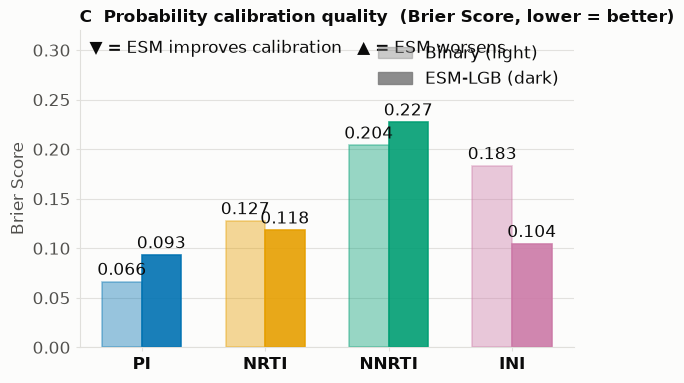

In [4]:
# ── Panel C: Brier Score comparison (binary vs ESM, by drug class) ────────
def plot_panel_c(ax, pred_df):
    ax.set_title("C  Probability calibration quality  (Brier Score, lower = better)",
                 loc="left", fontweight="bold", fontsize=12, pad=6)

    # compute per-class Brier scores from predictions
    brier_rows = []
    for cls in CO:
        sub = pred_df[pred_df["class"] == cls].copy()
        if len(sub) < 10: continue
        yt = sub["y_true"].to_numpy(float)
        bp = pd.to_numeric(sub["binary_prob"],  errors="coerce").to_numpy(float)
        ep = pd.to_numeric(sub["esm_lgb_prob"], errors="coerce").to_numpy(float)
        ok_b = np.isfinite(bp); ok_e = np.isfinite(ep)
        if ok_b.sum() < 5: continue
        brier_rows.append({
            "class": cls,
            "Binary": float(np.mean((yt[ok_b] - bp[ok_b])**2)),
            "ESM":    float(np.mean((yt[ok_e] - ep[ok_e])**2)) if ok_e.sum()>=5 else np.nan,
        })
    bdf = pd.DataFrame(brier_rows).set_index("class").reindex(CO)

    x     = np.arange(len(CO))
    width = 0.32
    for xi, cls in enumerate(CO):
        b_val = bdf.loc[cls, "Binary"]
        e_val = bdf.loc[cls, "ESM"]
        # Binary bar (lighter shade)
        ax.bar(xi - width/2, b_val, width, color=CC[cls], alpha=0.40,
               edgecolor=CC[cls], lw=1.2, label="Binary" if xi==0 else None)
        # ESM bar (full color)
        if not np.isnan(e_val):
            ax.bar(xi + width/2, e_val, width, color=CC[cls], alpha=0.90,
                   edgecolor=CC[cls], lw=1.2, label="ESM-LGB" if xi==0 else None)
        # value labels
        ax.text(xi - width/2, b_val + 0.003, f"{b_val:.3f}", ha="center",
                va="bottom", fontsize=12, color=INK)
        if not np.isnan(e_val):
            delta = e_val - b_val
            ax.text(xi + width/2, e_val + 0.003, f"{e_val:.3f}", ha="center",
                    va="bottom", fontsize=12, color=INK)

    ax.set_xticks(x)
    ax.set_xticklabels(CO, fontsize=12, fontweight="bold")
    for tick, cls in zip(ax.get_xticklabels(), CO):
        tick.set_color(INK)
    ax.set_ylabel("Brier Score", fontsize=12)
    ax.set_ylim(0, 0.32)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(length=3, color=GRID)
    ax.yaxis.grid(True, color=GRID, lw=0.8, alpha=0.9)
    ax.set_axisbelow(True)

    # legend
    import matplotlib.patches as mp
    leg = [mp.Patch(fc="gray", alpha=0.40, ec="gray", label="Binary (light)"),
           mp.Patch(fc="gray", alpha=0.90, ec="gray", label="ESM-LGB (dark)")]
    ax.legend(handles=leg, frameon=False, fontsize=12, loc="upper right")
    ax.text(0.02, 0.97, "▼ = ESM improves calibration   ▲ = ESM worsens",
            transform=ax.transAxes, fontsize=12, va="top", color=INK)

fig, ax = plt.subplots(figsize=(6, 4), facecolor=SURFACE)
plot_panel_c(ax, pred)
fig.tight_layout()
save_panel(fig, "fig5C_calibration.png")
plt.show()

saved fig5_combined.png


saved fig5_combined.pdf


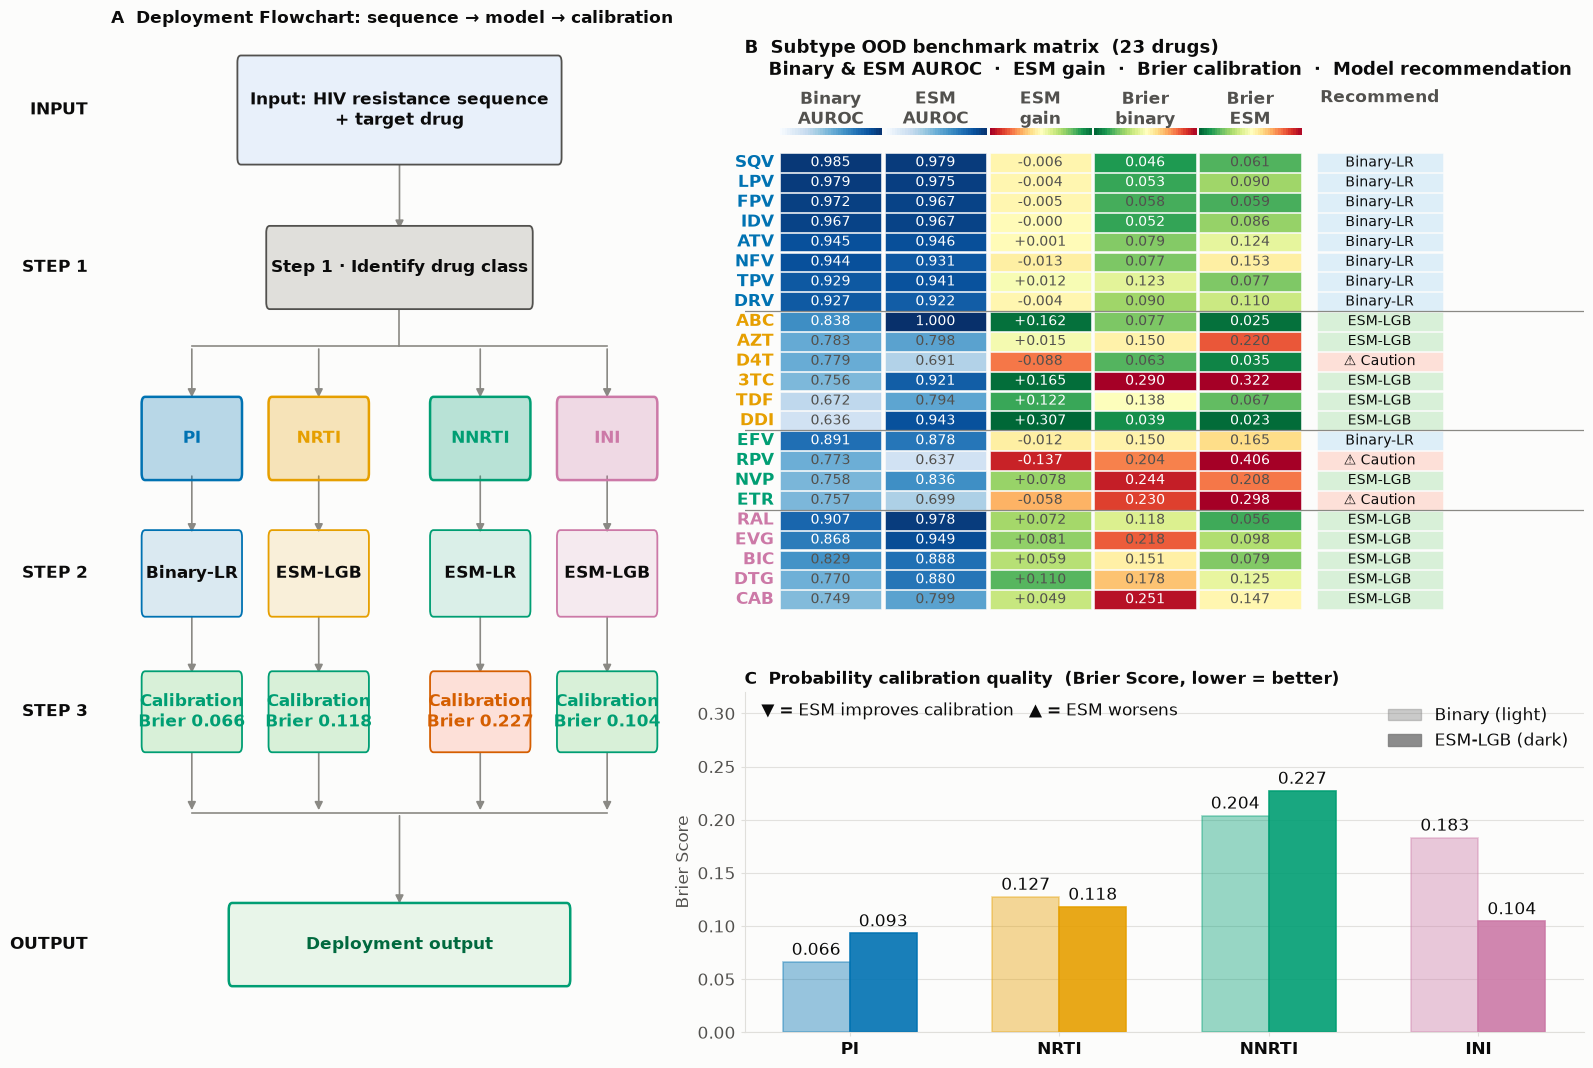

In [5]:
# ── Combined 3-panel Figure 5 ────────────────────────────────────────────
# Assembles panels by calling plot functions directly (no PNG reading)
fig = plt.figure(figsize=(19, 13), facecolor=SURFACE)
gs_outer = fig.add_gridspec(1, 2, width_ratios=[1.1, 1.6], wspace=0.08)
ax_a = fig.add_subplot(gs_outer[0])
gs_right = gs_outer[1].subgridspec(2, 1, height_ratios=[1.7, 1.0], hspace=0.18)
ax_b = fig.add_subplot(gs_right[0])
ax_c = fig.add_subplot(gs_right[1])

plot_panel_a(ax_a)
plot_panel_b(ax_b, mat)
plot_panel_c(ax_c, pred)

for pth in [FIG_DIR/"fig5_combined.png", FIG_DIR/"fig5_combined.pdf"]:
    fig.savefig(pth, dpi=240 if pth.suffix==".png" else None,
                bbox_inches="tight", facecolor=SURFACE)
    print("saved", pth.name)
plt.show()


---
## Supplementary · ESM vs pairwise-interaction features (Random CV)

Evidence that ESM gain is not from pairwise site interactions: binary+interactions generally does not beat binary, yet ESM still gains on some NRTI/NNRTI drugs—suggesting ESM captures higher-order sequence context.
- This panel uses Random CV (the epistasis probe runs under Random CV only).
- INI is excluded (probe covers PI/NRTI/NNRTI, 18 drugs total).

saved fig5_supp_epistasis.png


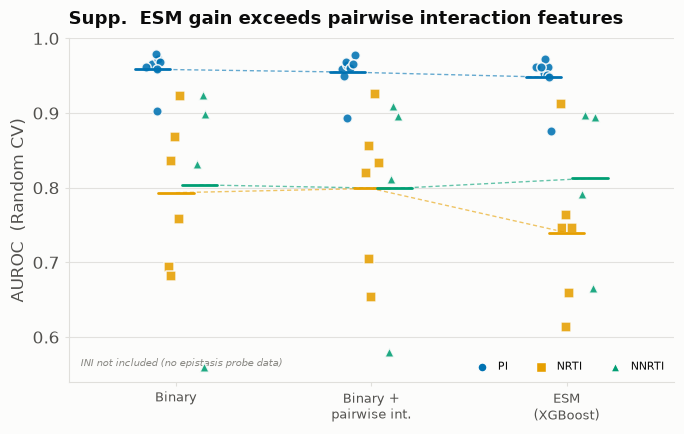

In [6]:
def plot_supp_epistasis(ax, epi_df):
    rng=np.random.default_rng(42)
    cls_list=[c for c in CLASS_ORDER if c in epi_df["class"].values]
    x_labels=["Binary","Binary +\npairwise int.","ESM\n(XGBoost)"]
    x_pos=np.array([0,1,2])
    for ci,cls in enumerate(cls_list):
        sub=epi_df[epi_df["class"]==cls].copy()
        col=CLASS_COLOR[cls]; mark=CLASS_MARKER[cls]
        offset=(ci-len(cls_list)/2+0.5)*0.12
        means=[]
        for xi,cn in enumerate(["binary","binary_int","esm_xgb"]):
            vals=pd.to_numeric(sub[cn],errors="coerce").dropna().to_numpy()
            jx=x_pos[xi]+offset+rng.uniform(-0.04,0.04,size=len(vals))
            ax.scatter(jx,vals,s=46,marker=mark,color=col,
                       edgecolor=SURFACE,lw=1.1,alpha=0.88,zorder=4)
            if len(vals):
                ax.plot([x_pos[xi]+offset-0.09,x_pos[xi]+offset+0.09],
                        [vals.mean(),vals.mean()],color=col,lw=2.0,
                        solid_capstyle="round",zorder=5)
                means.append(vals.mean())
        if len(means)==3:
            ax.plot(x_pos+offset,means,color=col,lw=1.0,
                    ls=(0,(3,2)),alpha=0.6,zorder=3)
    ax.set_xticks(x_pos,x_labels,fontsize=9.5)
    ax.set_ylabel("AUROC  (Random CV)")
    ax.set_title("Supp.  ESM gain exceeds pairwise interaction features",
                 loc="left",fontweight="bold",pad=10)
    style_axis(ax)
    ax.yaxis.grid(True,color=GRID,lw=0.8,alpha=0.9); ax.set_axisbelow(True)
    ax.set_xlim(-0.55,2.55)
    handles=[ax.scatter([],[],s=42,marker=CLASS_MARKER[c],color=CLASS_COLOR[c],
                        edgecolor=SURFACE,lw=1.0,label=c) for c in cls_list]
    ax.legend(handles=handles,frameon=False,ncol=3,loc="lower right",
              fontsize=8.0,handletextpad=0.4)
    ax.text(0.02,0.04,"INI not included (no epistasis probe data)",
            transform=ax.transAxes,ha="left",va="bottom",
            fontsize=7.5,color=INK3,style="italic")

fig,ax=plt.subplots(figsize=(7.0,4.5),facecolor=SURFACE)
plot_supp_epistasis(ax,epi); fig.tight_layout()
save_panel(fig,"fig5_supp_epistasis.png"); 
plt.show()

In [7]:
print("=== Main panels ===")
for fn in ["fig5_combined.png","fig5_combined.pdf",
           "fig5A_deployment_quadrant.png","fig5B_per_drug_ood_auroc.png",
           "fig5C_class_recommendation.png","fig5D_calibration.png"]:
    print(f"  {fn}: {'OK' if (FIG_DIR/fn).exists() else 'MISSING'}")
print("\n=== Supplementary ===")
for fn in ["fig5_supp_epistasis.png"]:
    print(f"  {fn}: {'OK' if (FIG_DIR/fn).exists() else 'MISSING'}")
print("\n=== Data outputs ===")
for fn in ["fig5_deployment_metrics.csv","fig5_epistasis_metrics.csv","fig5D_brier_scores.csv"]:
    print(f"  {fn}: {'OK' if (OUT_DIR/fn).exists() else 'MISSING'}")

=== Main panels ===
  fig5_combined.png: OK
  fig5_combined.pdf: OK
  fig5A_deployment_quadrant.png: MISSING
  fig5B_per_drug_ood_auroc.png: MISSING
  fig5C_class_recommendation.png: MISSING
  fig5D_calibration.png: MISSING

=== Supplementary ===
  fig5_supp_epistasis.png: OK

=== Data outputs ===
  fig5_deployment_metrics.csv: OK
  fig5_epistasis_metrics.csv: OK
  fig5D_brier_scores.csv: MISSING
